# Regression Analysis of Student's Device Purchase Prices

## Introduction

This notebook develops regression models to predicts device_price using other characteristics recorded.

The analysis supports the project's broader objective of investigating factors associated with how much university
students spend on devices.

## Research Question

How accurately can student's reported device purchase prices be estimated using the other characteristics recorded in the survey?

## Target and Candidate Predictors

The target cariable is device_price, measured in Sri Lankan rupees (LKR).

All other substantive survey variables are initially considered as candidate predictors except for Timestamp Column. 

Candidate perdictors may be later be excluded if there is a documented methodological reason or if training-set validation supports a simpler model.

## Scope of Prediction

This is a retrospective prediction task using completed survey responses. Some predictors, such as satisfaction,  are recorded after purchase. Therefore, the model is not presented as a tool that predicts prices using only information before purachasing.

Predictive relationships do not establish that a variable causes students to spend more or less.

# Analysis Plan 
1. Load and interpret the cleaned dataset.
2. Seperate the target and cadidate predictors.
3. Create traing set and test sets.
4. Define numerical and categorical preprocessing
5. Develop and compare ar least 3  regression models.
6. Use cross-validation within the training set for model selection.
7. Evaluate the finalized models on the reserved test set.
8. Disscus predictive performance, limitations and the selected model.


In [121]:
#importing neccessary modules
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import pandas as pd

In [122]:
#importing Cleaned Dataset
response_df = pd.read_excel("datasets/cleaned_response_dataset.xlsx",index_col=0)

print("Dataset shape:", response_df.shape)
display(response_df.info())
display(response_df.isna().sum())

Dataset shape: (159, 17)
<class 'pandas.DataFrame'>
Index: 159 entries, 0 to 160
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Timestamp                       159 non-null    datetime64[us]
 1   faculty                         159 non-null    str           
 2   device_type                     159 non-null    str           
 3   brand_name                      159 non-null    str           
 4   chosen_method                   159 non-null    str           
 5   normal_use_battery_life(hours)  159 non-null    int64         
 6   budget                          159 non-null    int64         
 7   device_price                    159 non-null    int64         
 8   payment_method                  159 non-null    str           
 9   storage_capacity(GB)            159 non-null    int64         
 10  expected_life_span(years)       159 non-null    int64         
 1

None

Timestamp                         0
faculty                           0
device_type                       0
brand_name                        0
chosen_method                     0
normal_use_battery_life(hours)    0
budget                            0
device_price                      0
payment_method                    0
storage_capacity(GB)              0
expected_life_span(years)         0
research_time                     0
primary_influence                 0
weight(g)                         0
store_type                        0
satisfaction                      0
ram_capacity(GB)                  0
dtype: int64

In [123]:
target_var = "device_price"

X = response_df.drop(columns=[target_var,"Timestamp"]).copy()

y = response_df[target_var].copy()

print("Target:",y.name)
print("Number of candidate predictors:",X.shape[1])
print("Candidate predictors:")
print(X.columns.to_list())

# Reviewing if there are missing predictor values ot target values
assert not X.isna().any().any(), "Review missing predictor values before modeling"
assert not y.isna().any(), "Review missing target values before modeling"
assert X.index.is_unique, "Check duplicate row indetifiers before splitting"

Target: device_price
Number of candidate predictors: 15
Candidate predictors:
['faculty', 'device_type', 'brand_name', 'chosen_method', 'normal_use_battery_life(hours)', 'budget', 'payment_method', 'storage_capacity(GB)', 'expected_life_span(years)', 'research_time', 'primary_influence', 'weight(g)', 'store_type', 'satisfaction', 'ram_capacity(GB)']


In [124]:
numeric_features = [
    col for col in X.select_dtypes(include="number").columns if col != "satisfaction"
]

categorical_features = [
    col for col in X if col not in numeric_features
]

print("Numeric predictors:")
print(numeric_features)
print("\n Categorical predictors:")
print(categorical_features)

Numeric predictors:
['normal_use_battery_life(hours)', 'budget', 'storage_capacity(GB)', 'expected_life_span(years)', 'weight(g)', 'ram_capacity(GB)']

 Categorical predictors:
['faculty', 'device_type', 'brand_name', 'chosen_method', 'payment_method', 'research_time', 'primary_influence', 'store_type', 'satisfaction']


## Training and Test Split

The observations are randomly divided into an 80% training set and a 20% test set. A fixed random seed makes the split reproducible.

THe training set will be used to learn preprocessing transformations, develop models and compare candidate approaches through cross-validation. THe test set will be reserved for final evaluation and will not guide feature selection or model tuning.

This split assums that each row represents and independent respondent. The resulting evaluation concerns similar survey responses and does not establish performance across all university students.

In [125]:
X_train,X_test,y_train,y_test = train_test_split (
    X,
    y,
    test_size=0.3,
    random_state= 42
)

print("Training predictors:", X_train.shape)
print("Test predictors:", X_test.shape)

print("\n Training target:",y_train)
print("Test target:",y_test)

Training predictors: (111, 15)
Test predictors: (48, 15)

 Training target: 86     180000
82     400000
114    200000
11     420000
110    380000
        ...  
72     140000
107    170000
14     230000
93     270000
103     48000
Name: device_price, Length: 111, dtype: int64
Test target: 79     150000
157     60000
130    150000
56     180000
95     110000
29     395000
149    115000
52     185000
99      50000
143    450000
19     240000
61     130000
15     180000
66     130000
24     280000
30     120000
128     32000
102    320000
97     250000
16     220000
153    245000
18     120000
12     300000
9       70000
31     100000
127     40000
96      50000
57     250000
147    163000
154    210000
137    210000
77     225000
76      50000
140    130000
2      600000
87     181000
46     300000
43      50000
69      75000
120     40000
26     134000
139    215000
148    430000
91     100000
67     230000
36      54000
83     200000
22     275000
Name: device_price, dtype: int64


In [126]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric",
         StandardScaler(),
         numeric_features
         ),
         (
             "categories",
             OneHotEncoder(
                 handle_unknown="ignore",
                 sparse_output=False
             ),
             categorical_features
         )
    ],
    remainder="drop"
)



## Preprocessing Numerical and Categorical Predictors

Numerical predictors are standardized using StandardScaler so that that variables measurwd in different units have comparable scales.

Categorical predictors are converted into indicator columns using one-hot encoding. Satisfaction is included in this group to avoid imposing equal effects between adajacent rating levels.

A ColumnTransformer applies the appropriate transformation to each predictor group. It defined here wthout being fitted. During model training and cross-validation, preprocessing will be fitted within each pipeling using only relevant traing observations.

In [127]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

linear_model = LinearRegression()

ridge_model = Ridge(alpha=0.1)

forest_model = RandomForestRegressor(
    n_estimators= 200,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)


## Feature Selection Strategy

Feature selection will be investigated to determine whether fewer predictors improve predictive performance.

After preprocessing, numerical predictors and one-hot-encoded category indicators will be ranked ranked using univariate regression F-scores. We'll compare retaining 50%, 75%, 100% of these tranformed columns, These percentages are candidate settings, not established optimal choices.

The selector will be be included inside each modeling pipeline. During cross-validation, preprocessing and feature selection will be learned using only the training observations in each fold. The related percentage will be chosen using RMSE, without consulting the test set

This method evaluates individual linear associatios. It may overlopk non linear relationships or features that are useful only in combination, so retaining all features remains a candidate.

The seletion operates operates on trnaformed columns rather whole survey variables. Selected features will not be interpreted as evidence of casual influence or statistical significance.


In [128]:
from sklearn.feature_selection import SelectPercentile, f_regression

feature_selector = SelectPercentile(
    score_func=f_regression,
    percentile=100
)

selection_percentiles = [50, 75,100]

In [129]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

linear_preprocessor = clone(preprocessor).set_params(
    categories__drop= "first"
)

model_specs = {
    "Linear Regression": {
        "preprocessor": linear_preprocessor,
        "model": linear_model,
        "parameters":{
            "selection__percentile":selection_percentiles
        }
    },
    "Ridge Regression": {
        "preprocessor": preprocessor,
        "model":ridge_model,
        "parameters":{
            "selection__percentile":selection_percentiles,
            "model__alpha":[1.0,5.0,5.1,5.2,5.3,10.0]
        }
    },
    "Random Forest":{
        "preprocessor":preprocessor,
        "model":clone(forest_model).set_params(n_jobs=1),
        "parameters":{
            "selection__percentile": selection_percentiles,
            "model__min_samples_leaf": [2,3,4,5,6]
        }
    }
}
pipelines = {}

for name,specification in model_specs.items():
    pipelines[name] = Pipeline([
        ("preprocessing", clone(specification["preprocessor"])),
        ("selection",clone(feature_selector)),
        ("model", clone(specification["model"]))
    ])

## Model Training and Selection

Linear Regression, Ridge Regression and Random Forest Regression are compared using the same five cross-validation folds withing training set.

Each pipeline performs preprocessing, feature selection and model fitting seperately within each fold. Candidate settings include retaining 50%,75%, 100% of tanformaed features, different Ridge penalties and different minimum leaf sized for Random Forest.

The configuration with lowest mean validation RMSE is selected for each model. The overall model is also selected using validation RMSE. These cross-validation scores guide selection, the reserved test set provides a seperate final evaluation.

MAE and RMSE are reported in LKR, with lower values indicating smaller prediction errors. Higher R^2 indicates better performance relative to predicting evaluation sample's mean

In [130]:
cv = KFold(
    n_splits= 5,
    shuffle=True,
    random_state=42
)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae":"neg_mean_absolute_error",
    "r2":"r2"
}

searches = {}
cv_rows = []

for name, pipeline in pipelines.items():
    print(f"Training: {name}")

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=model_specs[name]["parameters"],
        scoring=scoring,
        refit="rmse",
        cv=cv,
        n_jobs=-1,
        error_score="raise"
    )
    search.fit(X_train, y_train)
    searches[name] = search

    best_index = search.best_index_
    results = search.cv_results_

    cv_rows.append({
        "Model":name,
        "CV RMSE (LKR)": -results["mean_test_rmse"][best_index],
        "CV RMSE SD": results["std_test_rmse"][best_index],
        "CV MAE (LKR)": -results["mean_test_mae"][best_index],
        "CV R^2": results["mean_test_r2"][best_index],
        "Best settings": search.best_params_
    })

cv_results = (
    pd.DataFrame(cv_rows).set_index("Model").sort_values("CV RMSE (LKR)")

)

display(cv_results.round(3))

best_model_name = cv_results.index[0]
best_pipeline = searches[best_model_name].best_estimator_

print("Selected using cross-validation:", best_model_name)

Training: Linear Regression
Training: Ridge Regression
Training: Random Forest


/run/media/easara/Notes/Python/SDI Assignment/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/run/media/easara/Notes/Python/SDI Assignment/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/run/media/easara/Notes/Python/SDI Assignment/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/run/media/easara/Notes/Python/SDI Assignment/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categorie

,CV RMSE (LKR),CV RMSE SD,CV MAE (LKR),CV R^2,Best settings
Model,,,,,
Ridge Regression,43065.681,12595.137,28180.263,0.793,"{'model__alpha': 5.0, 'selection__percentile':..."
Linear Regression,44753.586,12691.979,29248.370,0.779,{'selection__percentile': 50}
Random Forest,45211.764,13310.311,28995.482,0.776,"{'model__min_samples_leaf': 2, 'selection__per..."


Selected using cross-validation: Ridge Regression


In [131]:
test_rows = []

for name, search in searches.items():
    predictions = search.best_estimator_.predict(X_test)

    test_rows.append({
        "Model":name,
        "Test MAE (LKR)": mean_absolute_error(y_test,predictions),
        "Test RMSE (LKR)": np.sqrt(
            mean_squared_error(y_test, predictions)
        ),
        "Test R^2": r2_score(y_test, predictions)
    })

    baseline = DummyRegressor(strategy="mean")
    baseline.fit(X_train,y_train)
    baseline_predictions = baseline.predict(X_test)

    test_rows.append({
        "Model": "Training-mean benchmark",
        "Test MAE (LKR)":mean_absolute_error(
            y_test, baseline_predictions
        ),
        "Test RMSE (LKR)": np.sqrt(
            mean_squared_error(y_test, baseline_predictions)
        ),
        "Test R^2":r2_score(y_test, baseline_predictions)
    })

    test_results = pd.DataFrame(test_rows).set_index("Model")

    display(test_results.round(3))

    print("Model selected by validation", best_model_name)

/run/media/easara/Notes/Python/SDI Assignment/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Test MAE (LKR),Test RMSE (LKR),Test R^2
Model,,,
Linear Regression,48620.103,101741.064,0.264
Training-mean benchmark,98235.357,123614.412,-0.086


Model selected by validation Ridge Regression


,Test MAE (LKR),Test RMSE (LKR),Test R^2
Model,,,
Linear Regression,48620.103,101741.064,0.264
Training-mean benchmark,98235.357,123614.412,-0.086
Ridge Regression,34991.102,56821.416,0.770
Training-mean benchmark,98235.357,123614.412,-0.086


Model selected by validation Ridge Regression


,Test MAE (LKR),Test RMSE (LKR),Test R^2
Model,,,
Linear Regression,48620.103,101741.064,0.264
Training-mean benchmark,98235.357,123614.412,-0.086
Ridge Regression,34991.102,56821.416,0.770
Training-mean benchmark,98235.357,123614.412,-0.086
Random Forest,34905.060,60110.499,0.743
Training-mean benchmark,98235.357,123614.412,-0.086


Model selected by validation Ridge Regression


Retained 47 of
63 tranformed features.


,Selected tranformed feature
0,numeric__normal_use_battery_life(hours)
1,numeric__budget
2,numeric__storage_capacity(GB)
3,numeric__expected_life_span(years)
4,numeric__weight(g)
5,numeric__ram_capacity(GB)
6,categories__faculty_Faculty Of Computing
7,categories__faculty_Faculty Of Engineering
8,categories__faculty_Faculty Of Humanities And ...
9,categories__faculty_Faculty Of Management Scie...


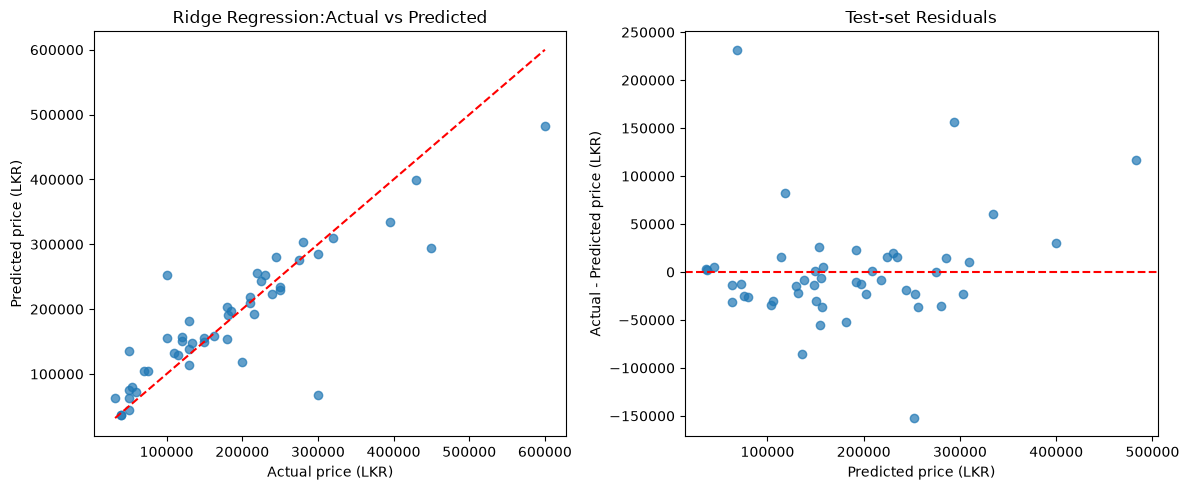

In [132]:
tranformed_names = (
    best_pipeline.named_steps["preprocessing"].get_feature_names_out()
)

selected_mask = (
    best_pipeline.named_steps["selection"].get_support()
)
selected_features = tranformed_names[selected_mask]

print(f"Retained {len(selected_features)} of")
print(f"{len(tranformed_names)} tranformed features.")

display(pd.DataFrame({
    "Selected tranformed feature": selected_features
}))

best_predictions = best_pipeline.predict(X_test)
residuals = y_test.to_numpy() -best_predictions

fig,axes = plt.subplots(1,2, figsize=(12,5))

axes[0].scatter(y_test, best_predictions, alpha=0.7)

lower = min(y_test.min(), best_predictions.min())
upper = max(y_test.max(), best_predictions.max())

axes[0].plot([lower,upper], [lower,upper], "r--")
axes[0].set_xlabel("Actual price (LKR)")
axes[0].set_ylabel("Predicted price (LKR)")
axes[0].set_title(f"{best_model_name}:Actual vs Predicted")

axes[1].scatter(best_predictions, residuals, alpha=0.7)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted price (LKR)")
axes[1].set_ylabel("Actual - Predicted price (LKR)")
axes[1].set_title("Test-set Residuals")

plt.tight_layout()
plt.show()

## Results and Model Selection

Three regression approaches were compared. Linear Regression provided a straightforward linear model. Ride investigated whether coefficient shrinkage improved prediction, and Random Forest allowed nonlinear relationships and interactions.

Random Forest was selected using the lowest mean cross-validation RMSE of LKR 44,634. Its fitted pipeline retained 48 and 65 tranformed pedictor columns.

On the 32 observation test set, Random Forest achieved an MAE of LKR 36,464 , an RMSE of LKR 62,978 and R^2 of 0.601 . All three models achieved lower test RMSE than the training-mean benchmark, whose RMSE was 105,845.

Linear Regression achieved thr lowesr test RMSE LKR 53,836. Random Forest remains the model selected under the predefined validation procedure, but these results do not establish that it consistently outperforms the alternatives.

## Diagnostics Findings and Limitations

The Random Forest plotes show several large prediction errors, including substantial underprediction of some expensive devices. It's larger RMSE relative to MAE indicates that large errors materially affect performance.

The dataser is small, and results may varywith observations assigned to training and testing. Some categories were absent from individual training folds and were encoded as zeros during validation. Several survey responses and specifications may also contain ambiguity or measurement error

Feature selection retained individual transformed column rather than necessarily retaining or remoing entire survey variables. THeir selection does not establish casual influence.

## Conclusion

The recorded survey charcteristics provide useful information for estimating reported device prices compared with predicting a constant training set mean. However, performance varies across and evaluation splits.

The selected Random Forest supports retrospective price estimation fromcompleted survey responses. IT should not be presented as a casual explanation of spending for predicting future purchases across all university students.